**Fake News Detection**

In [2]:
import pandas as pd
import numpy as np

https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

**Dataset**

In [3]:
fake_df = pd.read_csv('/content/drive/MyDrive/Fake News Dectection/Fake.csv.zip')
true_df = pd.read_csv('/content/drive/MyDrive/Fake News Dectection/True.csv.zip')

In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


**EDA**

In [6]:
#Add labels

fake_df['label'] = 1
true_df['label'] = 0

In [7]:
#Inspect the data
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [8]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [9]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [10]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [11]:
fake_df.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [12]:
true_df.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [13]:
#Train Test Split

from sklearn.model_selection import train_test_split

df = pd.concat([fake_df, true_df], ignore_index=True)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42)

In [14]:
print(train_df.shape)
print(test_df.shape)

(35918, 5)
(8980, 5)


In [15]:
#Verify class proportions
print(train_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.522997
0    0.477003
Name: proportion, dtype: float64
label
1    0.52294
0    0.47706
Name: proportion, dtype: float64


In [16]:
#Class Balance
train_df['label'].value_counts()

,count
label,
1,18785
0,17133


The subject variables exhibited near-perfect separation between classes, indicating target leakage. To ensure the model learns linguistic characteristics of misinformation rather than dataset-specific metadata, the subject feature was excluded from model training.

In [17]:
#Subject distribution
print(train_df["subject"].value_counts(),"\n\n")

print(pd.crosstab(
    train_df["subject"],
    train_df["label"]
))

subject
politicsNews       9056
worldnews          8077
News               7301
politics           5402
left-news          3569
Government News    1261
Middle-east         632
US_News             620
Name: count, dtype: int64 


label               0     1
subject                    
Government News     0  1261
Middle-east         0   632
News                0  7301
US_News             0   620
left-news           0  3569
politics            0  5402
politicsNews     9056     0
worldnews        8077     0


In [18]:
#Article Length

train_df["title_length"] = (
    train_df["title"]
    .str.split()
    .str.len()
)

train_df["text_length"] = (
    train_df["text"]
    .str.split()
    .str.len()
)

train_df.groupby("label")[
    ["title_length", "text_length"]
].describe()

title_length                                                    \
             count       mean       std  min   25%   50%   75%   max   
label                                                                  
0          17133.0   9.955408  1.696055  4.0   9.0  10.0  11.0  20.0   
1          18785.0  14.746074  4.348620  1.0  12.0  14.0  17.0  42.0   

      text_length                                                            
            count        mean         std  min    25%    50%    75%     max  
label                                                                        
0         17133.0  385.468511  275.810597  0.0  148.0  359.0  522.0  5172.0  
1         18785.0  423.008943  407.919150  0.0  240.0  364.0  506.0  8135.0

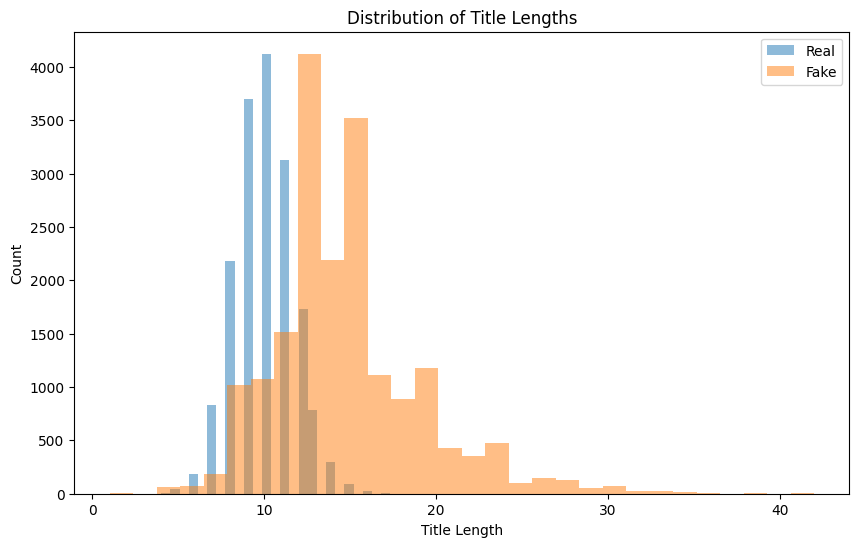

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    train_df[train_df["label"] == 0]["title_length"],
    bins=30,
    alpha=0.5,
    label="Real"
)

plt.hist(
    train_df[train_df["label"] == 1]["title_length"],
    bins=30,
    alpha=0.5,
    label="Fake"
)

plt.xlabel("Title Length")
plt.ylabel("Count")
plt.title("Distribution of Title Lengths")
plt.legend()
plt.show()

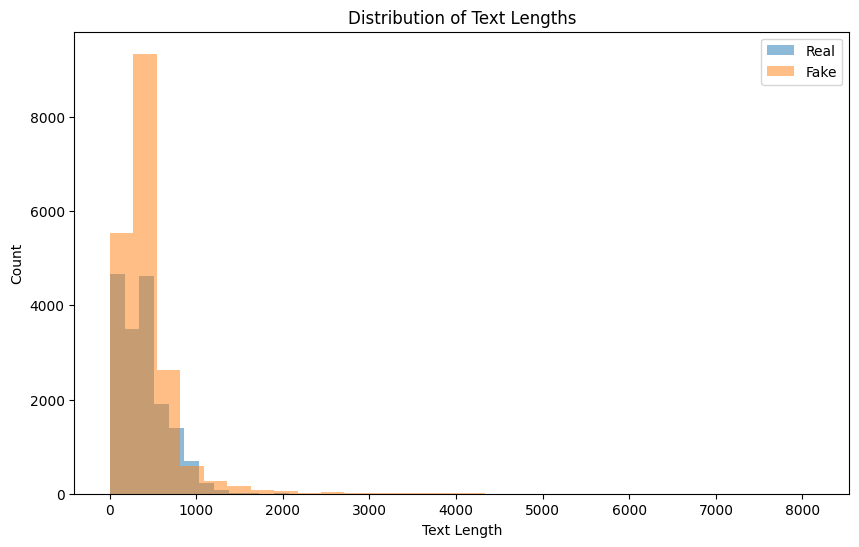

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df[train_df["label"] == 0]["text_length"],
    bins=30,
    alpha=0.5,
    label="Real"
)

plt.hist(
    train_df[train_df["label"] == 1]["text_length"],
    bins=30,
    alpha=0.5,
    label="Fake"
)

plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title("Distribution of Text Lengths")
plt.legend()
plt.show()

In [21]:
train_df.groupby("label")[
    ["title_length", "text_length"]
].agg(["mean", "median", "std"])

title_length                  text_length                   
              mean median       std        mean median         std
label                                                             
0         9.955408   10.0  1.696055  385.468511  359.0  275.810597
1        14.746074   14.0  4.348620  423.008943  364.0  407.919150

In [22]:
# T-test to determine if the difference is stat sig
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    train_df[train_df["label"] == 0]["title_length"],
    train_df[train_df["label"] == 1]["title_length"],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_val)

t_stat, p_val = ttest_ind(
    train_df[train_df["label"] == 0]["text_length"],
    train_df[train_df["label"] == 1]["text_length"],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_val)


T-statistic: -139.78314578974653
P-value: 0.0
T-statistic: -10.29448789892612
P-value: 8.131657750483397e-25


**Feature Engineering**

Although title length was symmetric across classes, text length exhibited right-skewed distributions in both fake and real news, with mean values exceeding medians. This suggests the presence of long-tail articles, particularly in the fake class, motivating the use of log-transformed features and ratio-based features rather than raw length statistics.

In [23]:
#Log transformed text length
train_df["log_text_length"] = np.log1p(train_df["text_length"]) #Compresses extreme long articles, makes distributions more normal

In [24]:
#Title-to-text ratio
train_df["title_text_ratio"] = train_df["title_length"] / train_df["text_length"] #Click bait vs article depth

**Pre-Process**

In [25]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text) #Remove url from text
    text = re.sub(r"[^a-z\s]", "", text) #removes all characters from the string text except for lowercase letters (a-z) and whitespace characters (\s)
    return text

train_df["clean_text"] = train_df["title"] + " " + train_df["text"]
test_df["clean_text"] = test_df["title"] + " " + test_df["text"]

train_df["clean_text"] = train_df["clean_text"].apply(clean_text)
test_df["clean_text"] = test_df["clean_text"].apply(clean_text)

train_df.head()

,title,text,subject,date,label,title_length,text_length,log_text_length,title_text_ratio,clean_text
36928,France invites U.S. to Dec. 13 summit on boost...,ACCRA (Reuters) - French President Emmanuel Ma...,worldnews,"November 30, 2017",0,13,402,5.998937,0.032338,france invites us to dec summit on boosting f...
30548,Trump keeps politics on his Thanksgiving menu,"WEST PALM BEACH, Fla./WASHINGTON (Reuters) - U...",politicsNews,"November 24, 2016",0,7,789,6.672033,0.008872,trump keeps politics on his thanksgiving menu ...
37469,Ireland's Fianna Fail party says will be elect...,DUBLIN (Reuters) - Ireland s second-largest pa...,worldnews,"November 24, 2017",0,14,75,4.330733,0.186667,irelands fianna fail party says will be electi...
9447,REPUBLICAN LEADER Implies He May Not Seat Roy ...,The New York Times just confirmed what we ve a...,politics,"Nov 12, 2017",1,13,359,5.886104,0.036212,republican leader implies he may not seat roy ...
24880,U.S. Senate approves Trump pick as top Fed reg...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"October 5, 2017",0,10,353,5.869297,0.028329,us senate approves trump pick as top fed regul...


**TF-IDF**

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(train_df["clean_text"])
X_test_tfidf = vectorizer.transform(test_df["clean_text"])

**Logistic Regression - Baseline**

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, train_df["label"])

LogisticRegression(max_iter=1000)

In [28]:
from sklearn.metrics import classification_report

preds = model.predict(X_test_tfidf)

print(classification_report(test_df["label"], preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



**Explainability**

Fake dataset:
- clickbait language
- informal tone
- political blogs

Real dataset:
- Reuters articles
- structured journalism
- formal reporting style

So TF-IDF + Logistic Regression is doing: source classification disguised as fake news detection. While the model achieved high performance, feature inspection revealed that it relied heavily on source-specific tokens such as 'reuters', indicating dataset bias and highlighting limitations of text-only fake news detection.

In [29]:
#Inspect most important words

feature_names = vectorizer.get_feature_names_out()
coeff = model.coef_[0]

top_fake = sorted(zip(coeff, feature_names), reverse=True)[:20]
top_real = sorted(zip(coeff, feature_names))[:20]

print("Top Fake Words:")
for w in top_fake:
    print(w)

print("\nTop Real Words:")
for w in top_real:
    print(w)


Top Fake Words:
(np.float64(9.773626475732229), 'video')
(np.float64(6.66626050569693), 'just')
(np.float64(5.635915133787844), 'image')
(np.float64(5.264403075320751), 'gop')
(np.float64(4.818476161423683), 'america')
(np.float64(4.8118378998009), 'hillary')
(np.float64(4.682267682116855), 'don')
(np.float64(4.477223509270697), 'obama')
(np.float64(4.463234096618228), 'wire')
(np.float64(4.386873705037492), 'didn')
(np.float64(4.352793897869291), 'breaking')
(np.float64(4.208597661776273), 'mr')
(np.float64(3.9176595812030675), 'doesn')
(np.float64(3.878467086600517), 've')
(np.float64(3.8121210940875416), 'watch')
(np.float64(3.807224177612988), 'american')
(np.float64(3.7527109595104076), 'like')
(np.float64(3.5976945971390797), 'images')
(np.float64(3.4642783399973114), 'rep')
(np.float64(3.243954078024566), 'll')

Top Real Words:
(np.float64(-24.945507611899114), 'reuters')
(np.float64(-17.439255149667076), 'said')
(np.float64(-8.397019911795685), 'trumps')
(np.float64(-5.89475440

**Remove Publisher Information,so the model doesnt learn publisher**

Initial analysis revealed that the model was leveraging publisher-specific tokens (e.g., ‘Reuters’) as predictive shortcuts. To improve generalization, these source identifiers were removed, and the model was retrained using only linguistically meaningful features. Although accuracy slightly decreased after removing source-specific leakage tokens, the model became more robust and less reliant on dataset artifacts, improving its generalization to real-world scenarios.

In [30]:
import re

def clean_text(text):
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove numbers + punctuation
    text = re.sub(r"[^a-z\s]", "", text)

    # remove known news source artifacts
    leakage_tokens = [
        "reuters",
        "washington",
        "breakingnews",
        "ap",
        "associatedpress",
    ]

    for token in leakage_tokens:
        text = text.replace(token, "")

    # collapse extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

train_df["clean_text"] = train_df["title"] + " " + train_df["text"]
test_df["clean_text"] = test_df["title"] + " " + test_df["text"]

train_df["clean_text"] = train_df["clean_text"].apply(clean_text)
test_df["clean_text"] = test_df["clean_text"].apply(clean_text)

train_df.head()



,title,text,subject,date,label,title_length,text_length,log_text_length,title_text_ratio,clean_text
36928,France invites U.S. to Dec. 13 summit on boost...,ACCRA (Reuters) - French President Emmanuel Ma...,worldnews,"November 30, 2017",0,13,402,5.998937,0.032338,france invites us to dec summit on boosting fi...
30548,Trump keeps politics on his Thanksgiving menu,"WEST PALM BEACH, Fla./WASHINGTON (Reuters) - U...",politicsNews,"November 24, 2016",0,7,789,6.672033,0.008872,trump keeps politics on his thanksgiving menu ...
37469,Ireland's Fianna Fail party says will be elect...,DUBLIN (Reuters) - Ireland s second-largest pa...,worldnews,"November 24, 2017",0,14,75,4.330733,0.186667,irelands fianna fail party says will be electi...
9447,REPUBLICAN LEADER Implies He May Not Seat Roy ...,The New York Times just confirmed what we ve a...,politics,"Nov 12, 2017",1,13,359,5.886104,0.036212,republican leader implies he may not seat roy ...
24880,U.S. Senate approves Trump pick as top Fed reg...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"October 5, 2017",0,10,353,5.869297,0.028329,us senate proves trump pick as top fed regulat...


In [31]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train2 = vectorizer.fit_transform(train_df["clean_text"])
X_test2 = vectorizer.transform(test_df["clean_text"])

model = LogisticRegression(max_iter=1000)
model.fit(X_train2, train_df["label"])

preds = model.predict(X_test2)

print(classification_report(test_df["label"], preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4284
           1       0.99      0.98      0.98      4696

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [32]:
#Inspect most important words

feature_names = vectorizer.get_feature_names_out()
coeff = model.coef_[0]

top_fake = sorted(zip(coeff, feature_names), reverse=True)[:20]
top_real = sorted(zip(coeff, feature_names))[:20]

print("Top Fake Words:")
for w in top_fake:
    print(w)

print("\nTop Real Words:")
for w in top_real:
    print(w)

Top Fake Words:
(np.float64(11.342728173741454), 'video')
(np.float64(7.499570410333097), 'just')
(np.float64(6.322059157059439), 'image')
(np.float64(6.075137363380885), 'gop')
(np.float64(5.305291633479986), 'america')
(np.float64(5.213650145466546), 'don')
(np.float64(5.207451664229645), 'hillary')
(np.float64(5.016529647116867), 'didn')
(np.float64(4.958534308027806), 'obama')
(np.float64(4.910408345653793), 'wire')
(np.float64(4.888449886553621), 'mr')
(np.float64(4.865376234455688), 'breaking')
(np.float64(4.389758975355134), 've')
(np.float64(4.362255263497375), 'doesn')
(np.float64(4.340962359712402), 'watch')
(np.float64(4.24203833508541), 'like')
(np.float64(4.1827988780177), 'american')
(np.float64(4.080850414694488), 'images')
(np.float64(4.043084960644924), 'rep')
(np.float64(3.714817544907281), 'll')

Top Real Words:
(np.float64(-18.99810345850661), 'said')
(np.float64(-9.112602922354329), 'trumps')
(np.float64(-6.413807639221442), 'wednesday')
(np.float64(-5.882625225709

The model is NOT detecting “truth”. It is detecting: journalistic style vs sensational/blog style language. Feature inspection revealed that the model primarily distinguishes between journalistic reporting language (e.g., ‘said’, ‘reporters’, structured temporal references) and informal or sensational language (e.g., ‘breaking’, ‘watch’, contractions). This indicates that the model captures stylistic differences rather than factual verification.

**Fake News Detective Report**

In [35]:
model3 = LogisticRegression(max_iter=1000)
model.fit(X_train2, train_df["label"])

probs = model.predict_proba(X_test2)

test_df["prob_fake"] = probs[:, 1]
test_df["prob_real"] = probs[:, 0]

In [36]:
feature_names = vectorizer.get_feature_names_out()
coeff = model.coef_[0]

word_importance = dict(zip(feature_names, coeff))

In [37]:
import numpy as np

def explain_article(text, vectorizer, model, top_k=10):
    # transform text
    X = vectorizer.transform([text])

    # get probability
    prob = model.predict_proba(X)[0]
    pred = model.predict(X)[0]

    # get feature names + coefficients
    feature_names = vectorizer.get_feature_names_out()
    coeff = model.coef_[0]

    # map word → importance
    words = vectorizer.transform([text]).nonzero()[1]

    contributions = []

    for idx in words:
        word = feature_names[idx]
        weight = coeff[idx]
        contributions.append((word, weight))

    # sort strongest signals
    top_fake = sorted(contributions, key=lambda x: x[1], reverse=True)[:top_k]
    top_real = sorted(contributions, key=lambda x: x[1])[:top_k]

    return {
        "prediction": "Fake" if pred == 1 else "Real",
        "prob_fake": prob[1],
        "prob_real": prob[0],
        "top_fake_words": top_fake,
        "top_real_words": top_real
    }

In [38]:
sample_text = test_df.iloc[0]["clean_text"]

result = explain_article(sample_text, vectorizer, model)

result

{'prediction': 'Fake',
 'prob_fake': np.float64(0.8166102578346702),
 'prob_real': np.float64(0.18338974216532977),
 'top_fake_words': [('america', np.float64(5.305291633479986)),
  ('doesn', np.float64(4.362255263497375)),
  ('images', np.float64(4.080850414694488)),
  ('today', np.float64(2.9206781770555708)),
  ('trump', np.float64(2.488432993134629)),
  ('recently', np.float64(2.0788638445658503)),
  ('time', np.float64(1.9895682638523207)),
  ('revealed', np.float64(1.6671564304473037)),
  ('live', np.float64(1.6650516709743313)),
  ('reports', np.float64(1.5910778695183976))],
 'top_real_words': [('said', np.float64(-18.99810345850661)),
  ('democratic', np.float64(-3.389772466372337)),
  ('statement', np.float64(-2.7447951284456344)),
  ('york', np.float64(-2.1212409240249035)),
  ('states', np.float64(-2.0501203332951996)),
  ('donald', np.float64(-2.024829599085865)),
  ('agency', np.float64(-2.007413460828235)),
  ('including', np.float64(-1.988537826313971)),
  ('court', np.

In [40]:
def pretty_print_explanation(result):
    print("\n🧠 FAKE NEWS DETECTIVE REPORT")
    print("-" * 40)
    print("Prediction:", result["prediction"])
    print("Fake probability:", round(result["prob_fake"], 3))
    print("Real probability:", round(result["prob_real"], 3))

    print("\n🚨 Strong Fake Signals:")
    for word, weight in result["top_fake_words"]:
        print(f"{word}: {round(weight, 3)}")

    print("\n✅ Strong Real Signals:")
    for word, weight in result["top_real_words"]:
        print(f"{word}: {round(weight, 3)}")

In [41]:
pretty_print_explanation(result)


🧠 FAKE NEWS DETECTIVE REPORT
----------------------------------------
Prediction: Fake
Fake probability: 0.817
Real probability: 0.183

🚨 Strong Fake Signals:
america: 5.305
doesn: 4.362
images: 4.081
today: 2.921
trump: 2.488
recently: 2.079
time: 1.99
revealed: 1.667
live: 1.665
reports: 1.591

✅ Strong Real Signals:
said: -18.998
democratic: -3.39
statement: -2.745
york: -2.121
states: -2.05
donald: -2.025
agency: -2.007
including: -1.989
court: -1.903
respond: -1.515


**Knowlegde Graph**

**Conclusion**